# Disaster Tweet Classification: Day 1 EDA

## Goal
Understand the training data before writing any preprocessing rules.

## Questions to answer
1. What does the dataset look like?
2. Is the target imbalanced?
3. How much data is missing in `keyword` and `location`?
4. Do disaster tweets differ in length from non-disaster tweets?
5. Which keywords appear most often in each class?
6. Are there duplicate tweets?
7. What patterns do I notice from reading real examples?

In [3]:
# Import Libraries
import os
import textwrap
import warnings
from IPython.display import display

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_PATH = "../data/train.csv"
FIGURES_DIR = "../outputs/figures"

os.makedirs(FIGURES_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

print("Success: Libraries imported")

Success: Libraries imported


In [6]:
# Load Data
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
display(df.head(10))

print(f"Tail:")
display(df.tail(20))

print("Success: Data Loaded")

Shape: (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1
5,8,NaN,NaN,#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires,1
6,10,NaN,NaN,"#flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs areas",1
7,13,NaN,NaN,I'm on top of the hill and I can see a fire in the woods...,1
8,14,NaN,NaN,There's an emergency evacuation happening now in the building across the street,1
9,15,NaN,NaN,I'm afraid that the tornado is coming to our area...,1


Tail:


,id,keyword,location,text,target
7593,10848,NaN,NaN,I just heard a really loud bang and everyone is asleep great,0
7594,10849,NaN,NaN,A gas thing just exploded and I heard screams and now the whole street smells of gas ... ??,1
7595,10850,NaN,NaN,NWS: Flash Flood Warning Continued for Shelby County until 08:00 PM Wednesday. http://t.co/nZ7ACKRrJi #tnwx,1
7596,10851,NaN,NaN,RT @LivingSafely: #NWS issues Severe #Thunderstorm Warnings for parts of #AR #NC #OK. Expect more trauma cases: http://t.co/FWqfCKNCQW,1
7597,10852,NaN,NaN,#??? #?? #??? #??? MH370: Aircraft debris found on La Reunion is from missing Malaysia Airlines ... http://t.co/5B7qT2YxdA,1
7598,10853,NaN,NaN,Father-of-three Lost Control of Car After Overtaking and Collided #BathAndNorthEastSomerset http://t.co/fa3FcnlN86,1
7599,10854,NaN,NaN,1.3 #Earthquake in 9Km Ssw Of Anza California #iPhone users download the Earthquake app for more information http://t.co/V3aZWOAmzK,1
7600,10855,NaN,NaN,Evacuation order lifted for town of Roosevelt: http://t.co/EDyfo6E2PU http://t.co/M5KxLPKFA1,1
7601,10859,NaN,NaN,#breaking #LA Refugio oil spill may have been costlier bigger than projected http://t.co/5ueCmcv2Pk,1
7602,10860,NaN,NaN,a siren just went off and it wasn't the Forney tornado warning ??,1


Success: Data Loaded


In [ ]:
print("Structure of training data")

print(f"Column Names: {df.columns.tolist()}")

print("Data Types")
print(df.dtypes.to_frame(name="dtypes"))

Structure of training data
Column Names: ['id', 'keyword', 'location', 'text', 'target']
Data Types
          dtypes
id         int64
keyword   object
location  object
text      object
target     int64


In [9]:
print("Missing Values")

missing_df = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values(by="missing_percent", ascending=False)

display(missing_df)

Missing Values


,missing_count,missing_percent
location,2533,33.27
keyword,61,0.80
id,0,0.00
text,0,0.00
target,0,0.00


Most missing values in location column

In [11]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,7613.0,NaN,NaN,NaN,5441.934848,3137.11609,1.0,2734.0,5408.0,8146.0,10873.0
keyword,7552,221,fatalities,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,5080,3341,USA,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,7613,7503,11-Year-Old Boy Charged With Manslaughter of Toddler: Report: An 11-year-old boy has been charged with manslaughter over the fatal sh...,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,7613.0,NaN,NaN,NaN,0.42966,0.49506,0.0,0.0,0.0,1.0,1.0


In [ ]:
print("Target Distribution table")

target_counts = df["target"].value_counts().sort_index()
target_perc = (df["target"].value_counts(normalize=True).sort_index() * 100).round(2)

target_summary = pd.DataFrame({
    "class_label": ["Not Disaster (0)", "Disaster (1)"],
    "count": [target_counts.get(0, 0), target_counts.get(1, 0)],
    "percentage": [target_perc.get(0, 0), target_perc.get(1, 0)]
})

display(target_summary)

Target Distribution table


,class_label,count,percentage
0,Not Disaster (0),4342,57.03
1,Disaster (1),3271,42.97


Almost balanced dataset but a bit inclined to "Not Disaster"

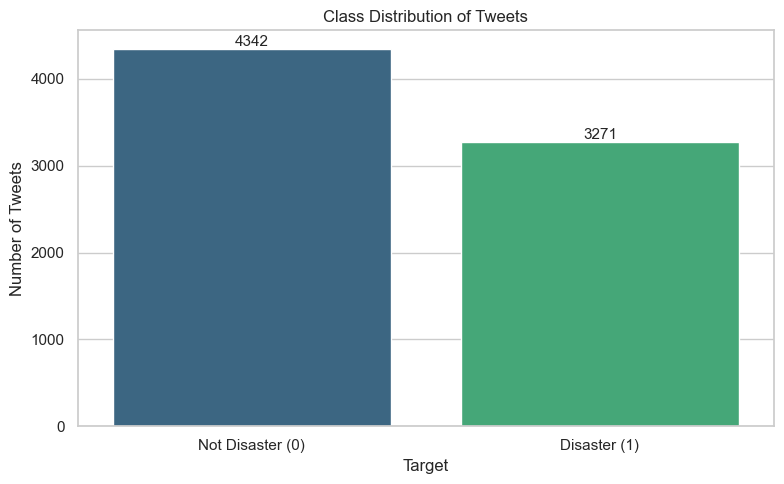

In [ ]:
print("Class Distribution Plot")

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="target", palette="viridis")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Class Distribution of Tweets")
plt.xlabel("Target")
plt.ylabel("Number of Tweets")
plt.xticks([0, 1], ["Not Disaster (0)", "Disaster (1)"])
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
print("Text Length Feature")
df["char_count"] = df["text"].astype(str).apply(len)
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))
df["avg_word_length"] = df["text"].astype(str).apply(
    lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0
)

display(df[["text", "char_count", "word_count", "avg_word_length"]].head())

Text Length Feature


,text,char_count,word_count,avg_word_length
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,69,13,4.384615
1,Forest fire near La Ronge Sask. Canada,38,7,4.571429
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,133,22,5.090909
3,"13,000 people receive #wildfires evacuation orders in California",65,8,7.125000
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,88,16,4.500000


In [15]:
print("Length Summary by Class")
length_summary = df.groupby("target")[["char_count", "word_count", "avg_word_length"]].agg(["mean", "median", "min", "max"]).round(2)
display(length_summary)

Length Summary by Class


char_count                 word_count                avg_word_length  \
             mean median min  max       mean median min max            mean   
target                                                                        
0           95.71  101.0   7  157      14.70   15.0   1  31            5.87   
1          108.11  115.0  14  151      15.17   15.0   2  30            6.47   

                            
       median   min    max  
target                      
0        5.54  2.25  16.86  
1        6.35  3.00  19.33

Tweet Length Distribution


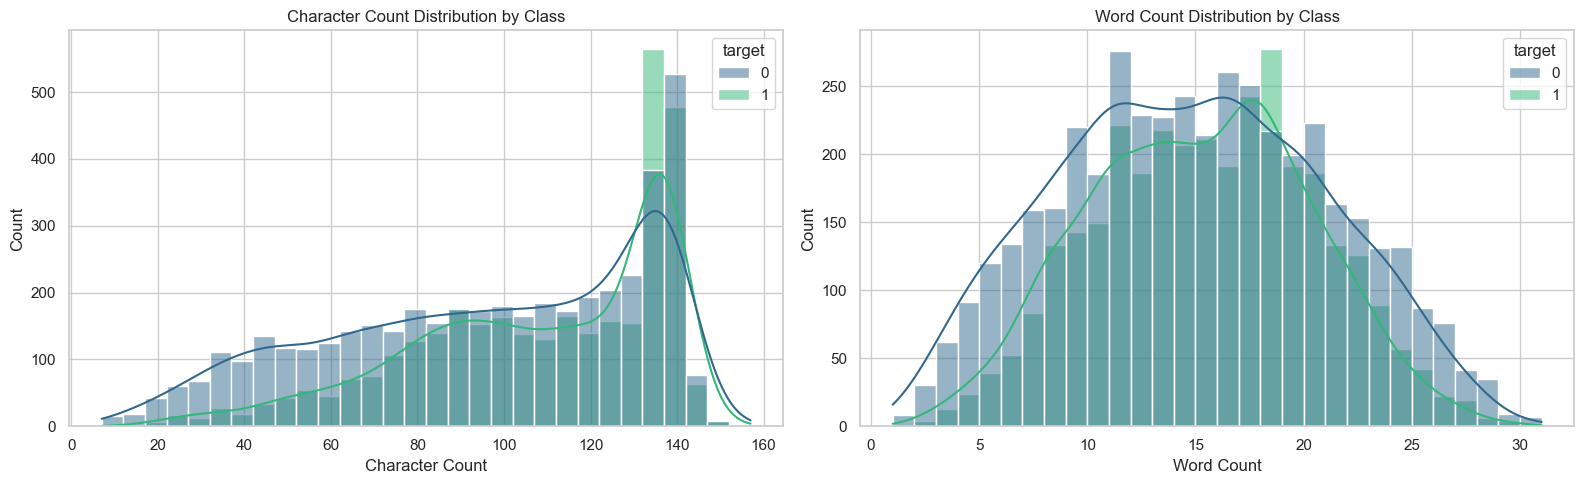

In [16]:
print("Tweet Length Distribution")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=df,
    x="char_count",
    hue="target",
    bins=30,
    kde=True,
    palette="viridis",
    ax=axes[0]
)
axes[0].set_title("Character Count Distribution by Class")
axes[0].set_xlabel("Character Count")

sns.histplot(
    data=df,
    x="word_count",
    hue="target",
    bins=30,
    kde=True,
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Word Count Distribution by Class")
axes[1].set_xlabel("Word Count")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/tweet_length_dist.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
print("Keyword coverage")

print("Unique keywords (including NaN):", df["keyword"].nunique(dropna=False))
print("Unique keywords (excluding NaN):", df["keyword"].nunique(dropna=True))

keyword_missing = df["keyword"].isna().sum()
location_missing = df["location"].isna().sum()

print(f"\nMissing keyword values: {keyword_missing} ({keyword_missing/len(df)*100:.2f}%)")
print(f"Missing location values: {location_missing} ({location_missing/len(df)*100:.2f}%)")

Keyword coverage
Unique keywords (including NaN): 222
Unique keywords (excluding NaN): 221

Missing keyword values: 61 (0.80%)
Missing location values: 2533 (33.27%)


In [18]:
print("Top Keyword Overall")

top_keywords_overall = (
    df["keyword"]
    .dropna()
    .astype(str)
    .str.lower()
    .value_counts()
    .head(20)
    .reset_index()
)

top_keywords_overall.columns = ["keyword", "count"]
display(top_keywords_overall)

Top Keyword Overall


,keyword,count
0,fatalities,45
1,deluge,42
2,armageddon,42
3,sinking,41
4,damage,41
5,harm,41
6,body%20bags,41
7,outbreak,40
8,evacuate,40
9,fear,40


Top Keyword by Class


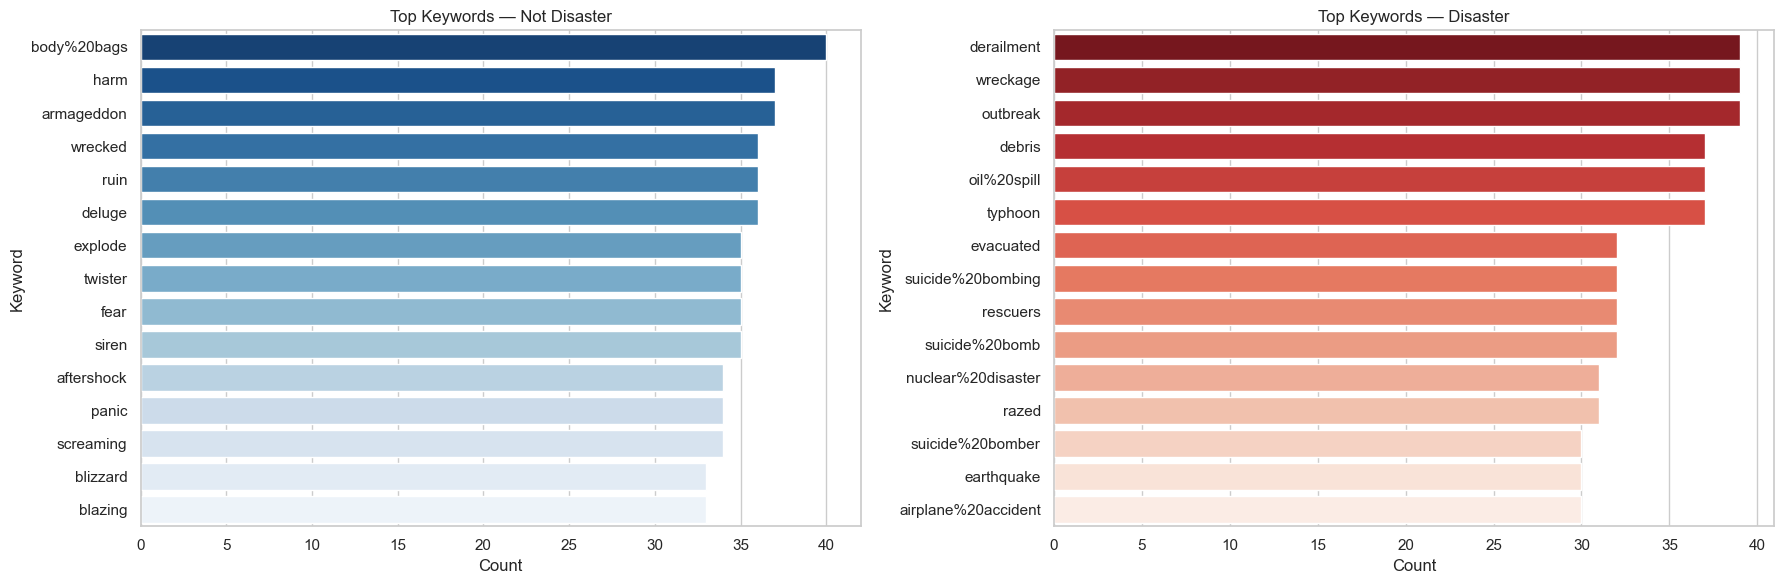

In [19]:
print("Top Keyword by Class")

top_keywords_non_disaster = (
    df[df["target"] == 0]["keyword"]
    .dropna()
    .astype(str)
    .str.lower()
    .value_counts()
    .head(15)
)

top_keywords_disaster = (
    df[df["target"] == 1]["keyword"]
    .dropna()
    .astype(str)
    .str.lower()
    .value_counts()
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    x=top_keywords_non_disaster.values,
    y=top_keywords_non_disaster.index,
    palette="Blues_r",
    ax=axes[0]
)
axes[0].set_title("Top Keywords — Not Disaster")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Keyword")

sns.barplot(
    x=top_keywords_disaster.values,
    y=top_keywords_disaster.index,
    palette="Reds_r",
    ax=axes[1]
)
axes[1].set_title("Top Keywords — Disaster")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Keyword")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/top_keywords.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
print("Keyword Crosstab for Signal Check")

keyword_target_crosstab = pd.crosstab(
    df["keyword"].fillna("missing_keyword"),
    df["target"],
    normalize="index"
).round(3)

keyword_target_crosstab.columns = ["pct_not_disaster", "pct_disaster"]
keyword_target_crosstab["total_count"] = df["keyword"].fillna("missing_keyword").value_counts()

display(
    keyword_target_crosstab
    .sort_values(by=["pct_disaster", "total_count"], ascending=[False, False])
    .head(20)
)

Keyword Crosstab for Signal Check


,pct_not_disaster,pct_disaster,total_count
keyword,,,
derailment,0.000,1.000,39
wreckage,0.000,1.000,39
debris,0.000,1.000,37
outbreak,0.025,0.975,40
oil%20spill,0.026,0.974,38
typhoon,0.026,0.974,38
suicide%20bombing,0.030,0.970,33
suicide%20bomber,0.032,0.968,31
bombing,0.069,0.931,29


In [21]:
print("Location Exploration")

top_locations = (
    df["location"]
    .dropna()
    .astype(str)
    .str.strip()
    .replace("", np.nan)
    .dropna()
    .value_counts()
    .head(20)
    .reset_index()
)

top_locations.columns = ["location", "count"]
display(top_locations)

Location Exploration


,location,count
0,USA,105
1,New York,73
2,United States,50
3,London,46
4,Nigeria,32
5,Canada,30
6,UK,27
7,"Los Angeles, CA",26
8,India,24
9,Mumbai,22


In [22]:
print("Duplicate Tweet Check")
duplicate_mask = df["text"].duplicated(keep=False)
duplicate_count = duplicate_mask.sum()
unique_duplicate_texts = df.loc[duplicate_mask, "text"].nunique()

print("Number of duplicate rows based on exact text:", duplicate_count)
print("Number of unique duplicated tweet texts:", unique_duplicate_texts)

display(
    df.loc[duplicate_mask, ["id", "keyword", "location", "text", "target"]]
    .sort_values(by="text")
    .head(20)
)

Duplicate Tweet Check
Number of duplicate rows based on exact text: 179
Number of unique duplicated tweet texts: 69


,id,keyword,location,text,target
4290,6094,hellfire,"Jubail IC, Saudi Arabia.",#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect,0
4299,6105,hellfire,?????? ??? ?????? ????????,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect,0
4312,6123,hellfire,?????? ???? ??????,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect,1
6363,9095,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
6373,9107,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
6377,9113,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
6378,9114,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
6392,9135,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
6366,9098,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
2828,4064,displaced,NaN,#KCA #VoteJKT48ID 12News: UPDATE: A family of 3 has been displaced after fired damaged housed near 90th and Osborn. Fire extinguished no iÛ_,1


In [23]:
print("Example Tweet by Class")

print("Sample tweets — Not Disaster (0)\n")
for i, tweet in enumerate(df[df["target"] == 0]["text"].sample(10, random_state=RANDOM_STATE), start=1):
    print(f"{i}. {tweet}\n")

print("\n" + "=" * 100 + "\n")

print("Sample tweets — Disaster (1)\n")
for i, tweet in enumerate(df[df["target"] == 1]["text"].sample(10, random_state=RANDOM_STATE), start=1):
    print(f"{i}. {tweet}\n")

Example Tweet by Class
Sample tweets — Not Disaster (0)

1. Everyday is a near death fatality for me on the road. Thank god is on my side.??

2. #Lifestyle Û÷It makes me sickÛª: Baby clothes deemed a Û÷hazardÛª http://t.co/0XrfVidxA2 http://t.co/oIHwgEZDCk

3. @Lenn_Len Probably. We are inundated with them most years!

4. A demoness with the voice of an angel. Like a siren's call beckoning me to the void. Don't ?? on thisÛ_ https://t.co/nPS3xpBKaQ

5. Next Man Up---AH SCREW THIS! I'm so tired of injuries.  

What happened to Camp Cupcake? More like Camp Cramp and Break.

6. I cant believe a fucking cis female is going to somehow claim to be offended over a transgendered female who's been attacked by media

7. Imagine getting flattened by Kurt Zouma

8. Now playing: Darude - Sandstorm - radio edit http://t.co/DUdAIrBBPo http://t.co/padosfyXnM

9. The Architect Behind Kanye WestÛªs Volcano https://t.co/MUSBIk7EJf

10. I'm gonna fight Taylor as soon as I get there.



Sample tweets 

In [24]:
print("Longest and Shortest tweets (by character count)")

print("Top 5 longest tweets:\n")
display(df[["text", "char_count", "word_count", "target"]].sort_values(by="char_count", ascending=False).head(5))

print("Top 5 shortest tweets:\n")
display(df[["text", "char_count", "word_count", "target"]].sort_values(by="char_count", ascending=True).head(5))

Longest and Shortest tweets (by character count)
Top 5 longest tweets:



,text,char_count,word_count,target
1270,when you're taking a shower and someone flushes the toilet and you have .1 second to GTFO or you get burned??????????????????????????????????????????????????,157,21,0
4801,It's was about 2:30 in the morning&amp;I went downstairs to watch some telly&amp;I accidentally made a loud bang&amp;my dad(who has a broken leg)walked-,152,23,0
614,@CAgov If 90BLKs&amp;8WHTs colluded 2 take WHT F @USAgov AUTH Hostage&amp;2 make her look BLK w/Bioterrorism&amp;use her lgl/org IDis ID still hers?@VP,151,22,1
635,@cspanwj If 90BLKs&amp;8WHTs colluded 2 take WHT F @USAgov AUTH Hostage&amp;2 make her look BLK w/Bioterrorism&amp;use her lgl/org IDis ID still hers?,150,22,1
633,@HowardU If 90BLKs&amp;8WHTs colluded 2 take WHT F @USAgov AUTH Hostage&amp;2 make her look BLK w/Bioterrorism&amp;use her lgl/org IDis ID still hers?,150,22,1


Top 5 shortest tweets:



,text,char_count,word_count,target
4890,Bad day,7,2,0
5115,Err:509,7,1,0
1882,Crushed,7,1,0
24,LOOOOOOL,8,1,0
3670,fatality,8,1,0


In [25]:
print("Frequent Words (without preprocessing)")

from collections import Counter
import re

def get_top_words(series, n=20):
    words = " ".join(series.astype(str).tolist()).lower()
    words = re.findall(r"\b[a-zA-Z]+\b", words)
    return Counter(words).most_common(n)

top_words_non_disaster = pd.DataFrame(get_top_words(df[df["target"] == 0]["text"]), columns=["word", "count"])
top_words_disaster = pd.DataFrame(get_top_words(df[df["target"] == 1]["text"]), columns=["word", "count"])

print("Top raw words — Not Disaster")
display(top_words_non_disaster)

print("Top raw words — Disaster")
display(top_words_disaster)

Frequent Words (without preprocessing)
Top raw words — Not Disaster


,word,count
0,t,2540
1,co,2212
2,http,1927
3,the,1913
4,i,1391
5,a,1265
6,to,1192
7,and,920
8,of,902
9,in,822


Top raw words — Disaster


,word,count
0,t,2659
1,co,2528
2,http,2382
3,the,1364
4,in,1164
5,a,935
6,of,928
7,to,757
8,and,506
9,on,420


## Day 1 Observations

### 1. Class balance
- The dataset is mildly imbalanced: 57.03% non-disaster vs 42.97% disaster tweets.
- This is not severe enough to require special handling at the EDA stage, but it means accuracy alone will not be a reliable metric later.
- F1-score should be the main evaluation metric in modeling.

### 2. Missing data
- The `text` column has no missing values, so it is the most reliable feature for the MVP.
- The `keyword` column has very few missing values and may be useful later, but it must be handled carefully.
- The `location` column has many missing values and appears noisy, so I will exclude it from the MVP model.

### 3. Tweet length
- Disaster and non-disaster tweets have overlapping character-count and word-count distributions.
- This suggests tweet length alone is not enough to separate the classes well.
- The model will need to learn actual language patterns, not just short-vs-long tweet differences.

### 4. Keywords
- Some keywords appear much more often in one class than the other.
- Keywords such as `derailment`, `wreckage`, and `outbreak` are strongly associated with disaster tweets.
- Some keyword values are URL-encoded (for example `body%20bags`), which means decoding/cleaning will be needed before any future keyword-based feature experiment.

### 5. Feature choice for MVP
- For the baseline model, `text` should be the only input feature.
- I will not use `location` in the MVP because it is noisy and incomplete.
- I will test `keyword` later as a controlled experiment, not in the first baseline.

### 6. Modeling implication
- The challenge is not just detecting disaster-related vocabulary.
- Many words can appear in both literal and figurative contexts, so contextual phrase patterns will matter.
- This supports starting with TF-IDF + classical linear models in the next phase.